In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [37]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import os
print(os.getcwd())


e:\Program\Kaggle\playground-series-s6e03\notebook


In [ ]:
samples = pd.read_csv("../data/sample_submission.csv")
samples.head()


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [ ]:
test = pd.read_csv("../data/test.csv")
test.head()


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [ ]:
df = pd.read_csv("../data/train.csv")
df.head()


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [ ]:
df.shape


(594194, 21)

In [ ]:
df.columns


Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [ ]:
df.describe(include='int64')


,id,SeniorCitizen,tenure
count,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258
std,171529.177263,0.317936,25.061922
min,0.000000,0.000000,1.000000
25%,148548.250000,0.000000,12.000000
50%,297096.500000,0.000000,35.000000
75%,445644.750000,0.000000,62.000000
max,594193.000000,1.000000,72.000000


In [ ]:
for col in df.columns[df.dtypes == 'str']:
    print(f"{col} : {df[col].nunique()}")


gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
Churn : 2


In [21]:
for col in df.select_dtypes(include=['object', 'category','str']).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: gender
gender
Female    298738
Male      295456
Name: count, dtype: int64

Column: Partner
Partner
Yes    309554
No     284640
Name: count, dtype: int64

Column: Dependents
Dependents
No     414362
Yes    179832
Name: count, dtype: int64

Column: PhoneService
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64

Column: OnlineBackup
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64

Column: DeviceProtection
DeviceProtection
No                     247377
Yes     

In [24]:
df.drop(columns=['id'], inplace=True)


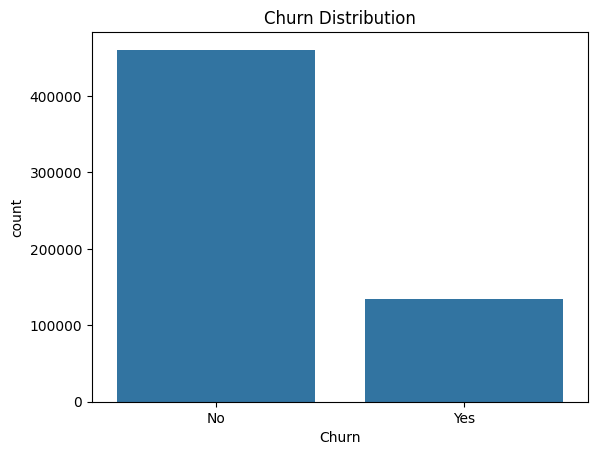

In [25]:
#Churn distribution

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


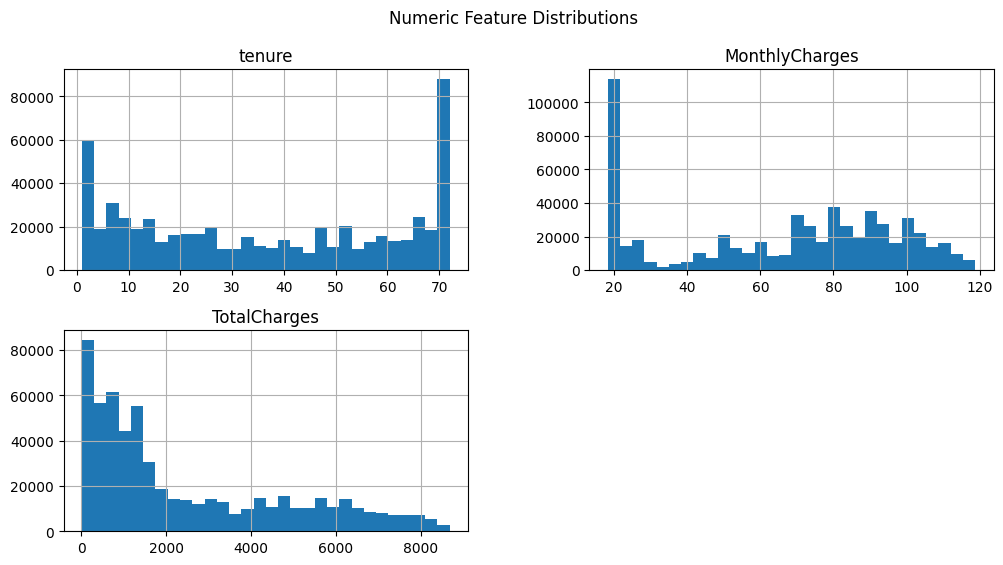

In [27]:
# Numerical features distribution

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].hist(bins=30, figsize=(12,6))
plt.suptitle("Numeric Feature Distributions")
plt.show()


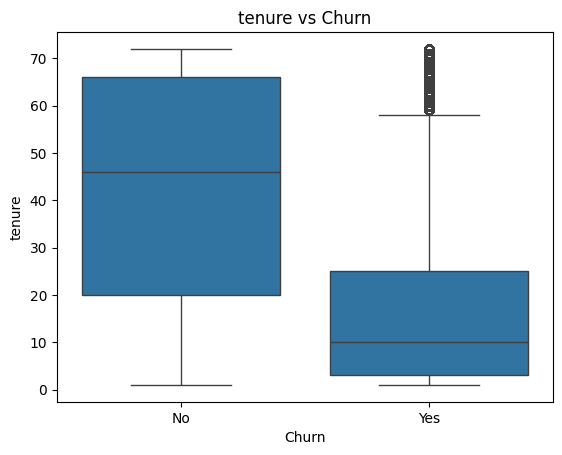

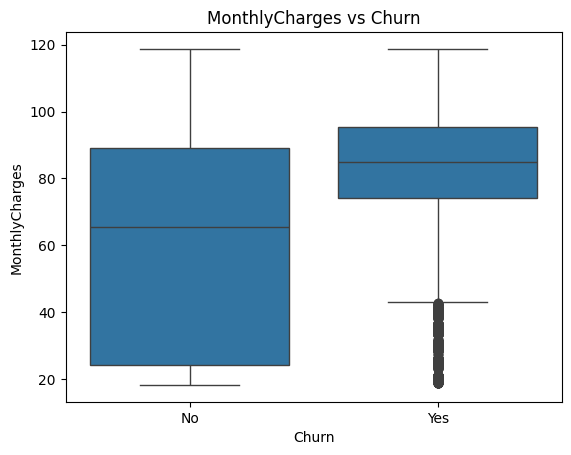

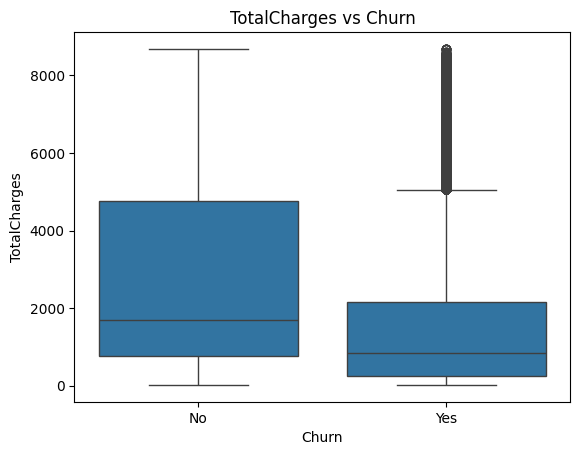

In [28]:
for col in num_cols:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()


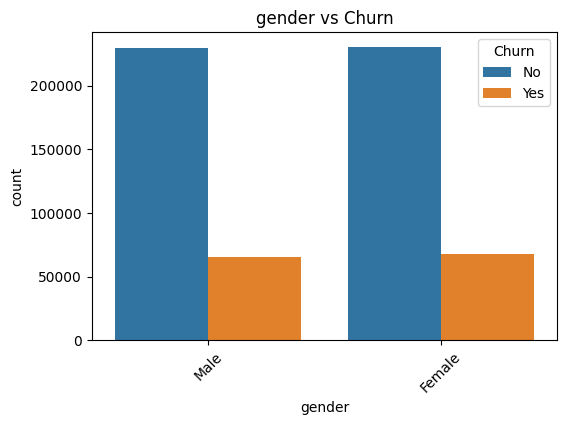

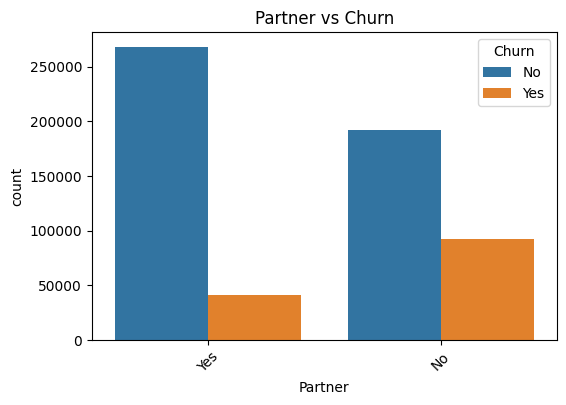

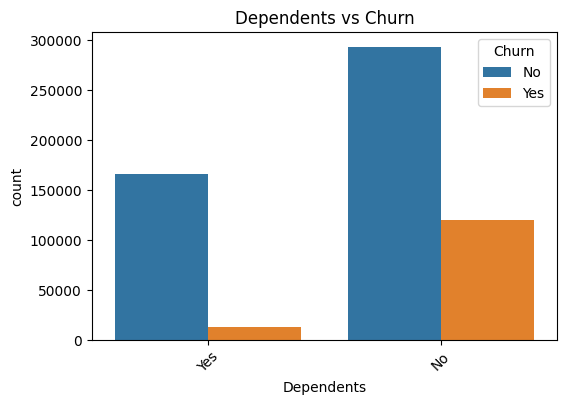

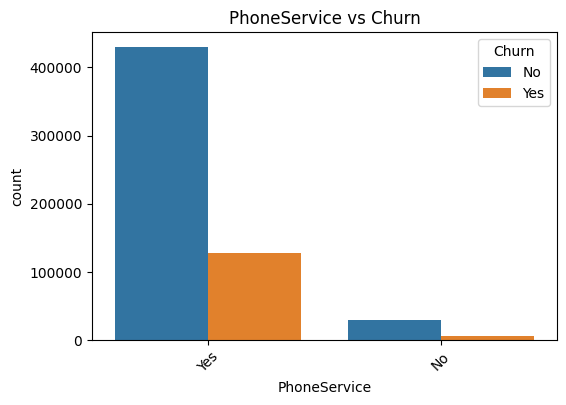

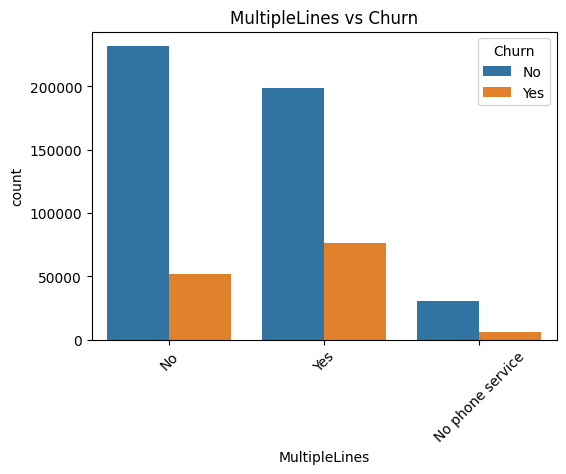

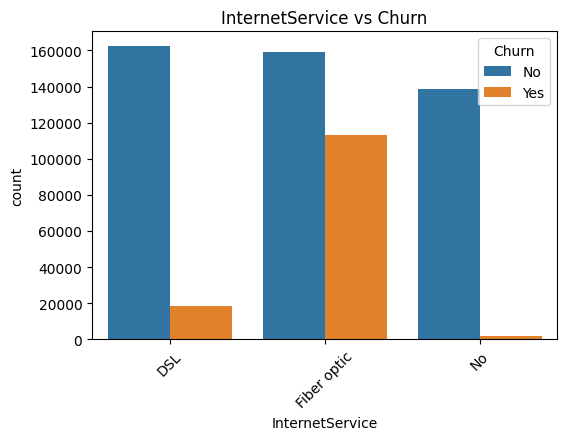

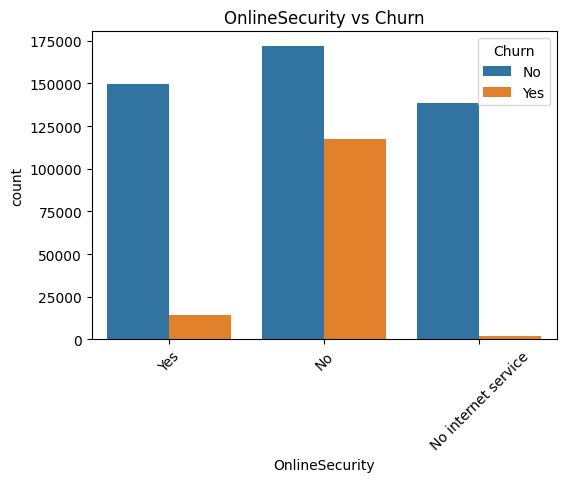

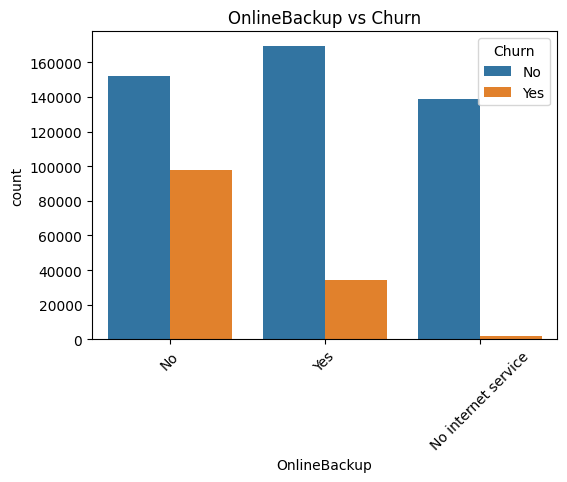

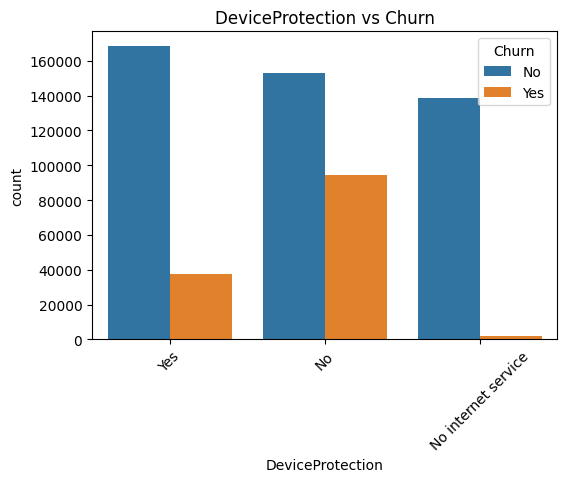

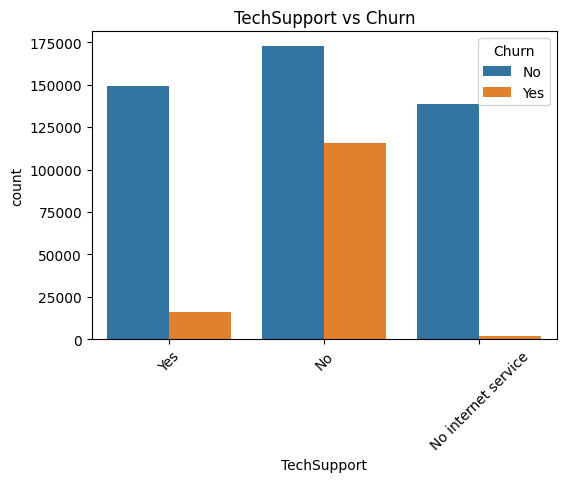

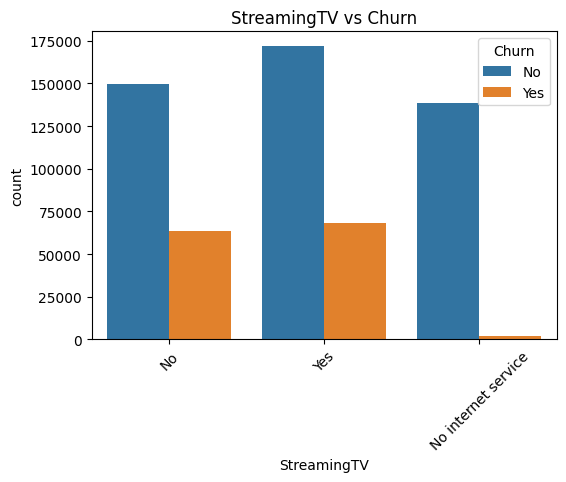

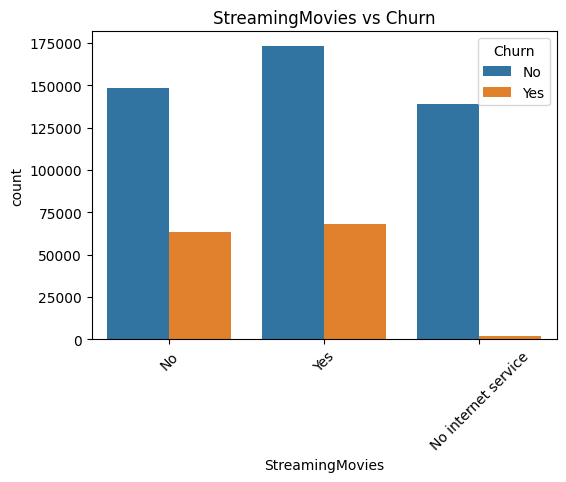

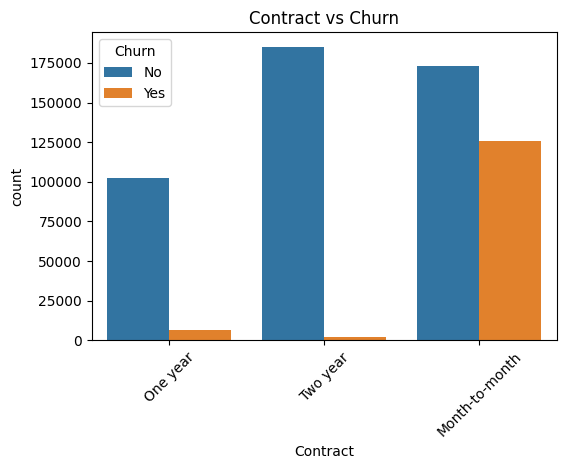

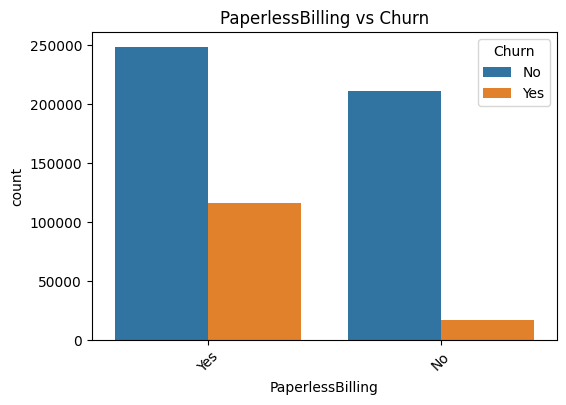

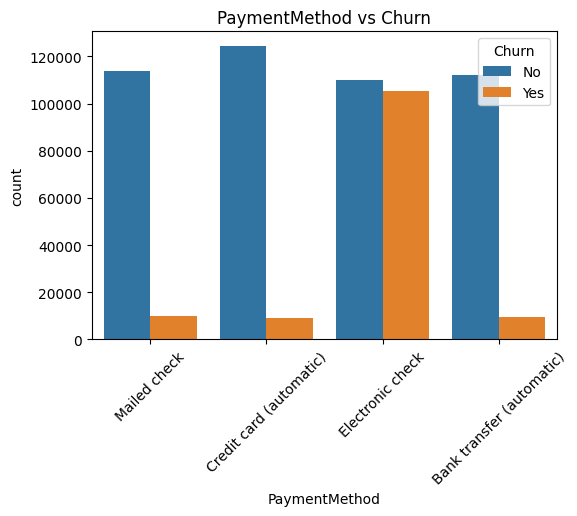

In [29]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.drop("Churn")

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()


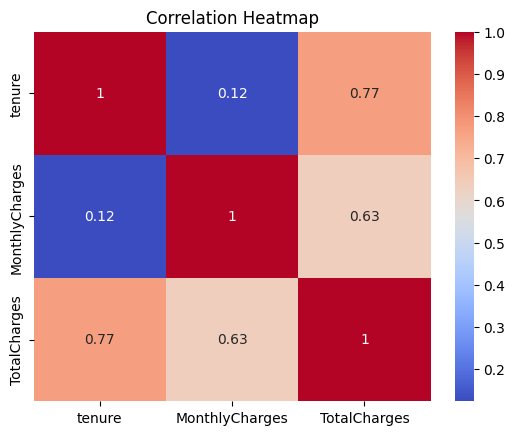

In [30]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix



In [33]:
# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes":1, "No":0})  # convert to 0/1

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=["object", "string"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns



In [34]:
# Preprocessing: OneHot for categorical, passthrough for numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Build pipeline with XGBoost
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])



In [35]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




In [36]:
# Fit model
xgb_model.fit(X_train, y_train)


e:\Program\Kaggle\playground-series-s6e03\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:22:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [38]:
# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

[[85075  7001]
 [ 9521 17242]]


Accuracy: 0.860971566573263
Precision: 0.711215608629295
Recall: 0.6442476553450659
F1 Score: 0.6760773242363644
ROC-AUC: 0.9163627680842915

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

Confusion Matrix:
 [[85075  7001]
 [ 9521 17242]]


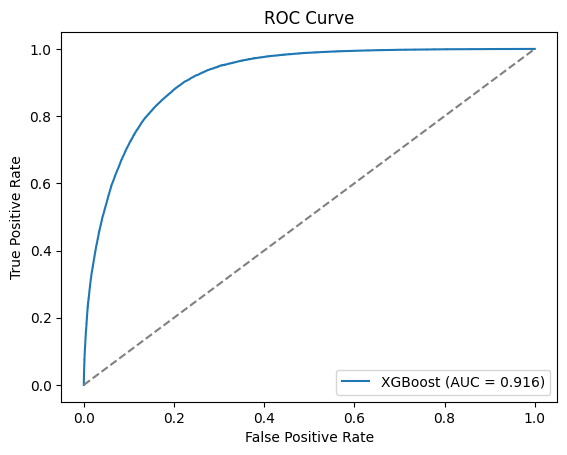

In [40]:
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve,accuracy_score,precision_score,recall_score,f1_score)

# Predictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label="XGBoost (AUC = %.3f)" % roc_auc_score(y_test, y_proba))
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

